### The data set has information about features of silhouette extracted from the images of different cars

Four "Corgie" model vehicles were used for the experiment: a double decker bus, Cheverolet van, Saab 9000 and an Opel Manta 400 cars. This particular combination of vehicles was chosen with the expectation that the bus, van and either one of the cars would be readily distinguishable, but it would be more difficult to distinguish between the cars.



In [269]:
# Numerical libraries
import numpy as np   

from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans

# to handle data in form of rows and columns 
import pandas as pd    

# importing ploting libraries
import matplotlib.pyplot as plt   

#importing seaborn for statistical plots
import seaborn as sns

from scipy.stats import zscore

### 1. Read the dataset using function .dropna() - to avoid dealing with NAs as of now

In [270]:
# reading the CSV file into pandas dataframe
data = pd.read_csv("vehicle.csv") 

In [271]:
data.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [272]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
compactness                    846 non-null int64
circularity                    841 non-null float64
distance_circularity           842 non-null float64
radius_ratio                   840 non-null float64
pr.axis_aspect_ratio           844 non-null float64
max.length_aspect_ratio        846 non-null int64
scatter_ratio                  845 non-null float64
elongatedness                  845 non-null float64
pr.axis_rectangularity         843 non-null float64
max.length_rectangularity      846 non-null int64
scaled_variance                843 non-null float64
scaled_variance.1              844 non-null float64
scaled_radius_of_gyration      844 non-null float64
scaled_radius_of_gyration.1    842 non-null float64
skewness_about                 840 non-null float64
skewness_about.1               845 non-null float64
skewness_about.2               845 non-null float64
hollows_ratio    

In [273]:
data.dropna(inplace=True)

In [274]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 813 entries, 0 to 845
Data columns (total 19 columns):
compactness                    813 non-null int64
circularity                    813 non-null float64
distance_circularity           813 non-null float64
radius_ratio                   813 non-null float64
pr.axis_aspect_ratio           813 non-null float64
max.length_aspect_ratio        813 non-null int64
scatter_ratio                  813 non-null float64
elongatedness                  813 non-null float64
pr.axis_rectangularity         813 non-null float64
max.length_rectangularity      813 non-null int64
scaled_variance                813 non-null float64
scaled_variance.1              813 non-null float64
scaled_radius_of_gyration      813 non-null float64
scaled_radius_of_gyration.1    813 non-null float64
skewness_about                 813 non-null float64
skewness_about.1               813 non-null float64
skewness_about.2               813 non-null float64
hollows_ratio    

### 2. Print/ Plot the dependent (categorical variable) - Class column

In [275]:
X = data.drop("class", axis=1)
y = data[["class"]]

In [276]:
y.tail()

,class
841,car
842,van
843,car
844,car
845,van


In [277]:
y.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 813 entries, 0 to 845
Data columns (total 1 columns):
class    813 non-null object
dtypes: object(1)
memory usage: 12.7+ KB


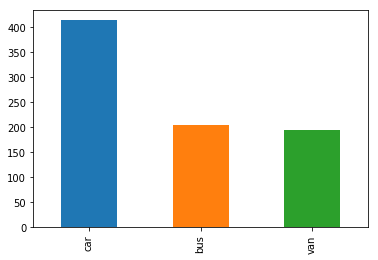

In [278]:
y['class'].value_counts().plot(kind = 'bar')

Since the variable is categorical, you can use value_counts function

In [279]:
y['class'].value_counts()

car    413
bus    205
van    195
Name: class, dtype: int64

### Check for any missing values in the data 

In [280]:
X.isnull().values.any()

False

In [281]:
y.isnull().values.any()

False

### 3. Standardize the data 

In [282]:
X = data.drop("class", axis=1)
X.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183


In [283]:
y.head()

,class
0,van
1,van
2,car
3,van
4,bus


Since the dimensions of the data are not really known to us, it would be wise to standardize the data using z scores before we go for any clustering methods.
You can use zscore function to do this

In [284]:
# convert the features into z scores as we do not know what units / scales were used and store them in new dataframe
# It is always adviced to scale numeric attributes in models that calculate distances.

X = X.apply(zscore)  # convert all attributes to Z scale 

In [285]:
X.head().T

,0,1,2,3,4
compactness,0.163231,-0.322874,1.256966,-0.079822,-1.052030
circularity,0.520408,-0.619123,0.845988,-0.619123,-0.130753
distance_circularity,0.060669,0.124067,1.518823,-0.002729,-0.763506
radius_ratio,0.264970,-0.836393,1.187734,-0.300595,1.068668
pr.axis_aspect_ratio,1.283254,-0.599253,0.530251,0.153750,5.173770
max.length_aspect_ratio,0.299721,0.085785,0.299721,0.085785,9.285029
scatter_ratio,-0.198517,-0.591720,1.162569,-0.742952,-0.591720
elongatedness,0.129648,0.514333,-1.152637,0.642562,0.514333
pr.axis_rectangularity,-0.217151,-0.606014,0.949438,-0.606014,-0.606014
max.length_rectangularity,0.766312,-0.337462,0.697326,-0.337462,-0.268476


### K - Means Clustering

### 4. Assign a dummy array called distortion

In [286]:
meanDistortions=[]

You can later use this array to plot the elbow plot

Text(0.5,1,'Selecting k with the Elbow Method')

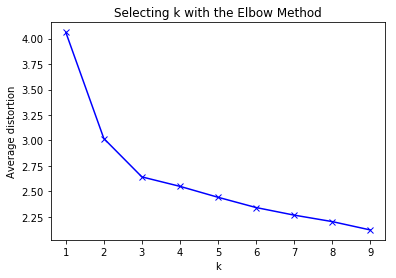

In [287]:
#Finding optimal no. of clusters
from scipy.spatial.distance import cdist
clusters=range(1,10)


for k in clusters:
    model=KMeans(n_clusters=k)
    model.fit(X1)
    prediction=model.predict(X1)
    meanDistortions.append(sum(np.min(cdist(X1, model.cluster_centers_, 'euclidean'), axis=1)) / X1.shape[0])


plt.plot(clusters, meanDistortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Average distortion')
plt.title('Selecting k with the Elbow Method')


### 5. Calculating distortion - C distance

In [348]:
from scipy.spatial.distance import cdist
clusters=range(1,10)


for k in clusters:
    model=KMeans(n_clusters=k)
    model.fit(X)
    prediction=model.predict(X)
    meanDistortions.append(sum(np.min(cdist(X, model.cluster_centers_, 'euclidean'), axis=1)) / X1.shape[0])


Iterating values of k from 1 to 10 fit K means model
Using c distance - Get the measure for Sum of squares error.

### 6. Plotting Elbow/ Scree Plot

Use Matplotlib to plot the scree plot - Note: Scree plot plots distortion vs the no of clusters

In [ ]:
#refer answer in Q4


### Find out the optimal value of K

# Optimal K value is 3 

### Using optimal value of K - Cluster the data. 
Note: Since the data has more than 2 dimension we cannot visualize the data. As an alternative, we can observe the centroids and note how they are distributed across different dimensions

In [351]:
# Let us first start with K = 3
final_model=KMeans(3)
final_model.fit(X)
prediction=final_model.predict(X)

dfCarsPred = X.copy()
dfCarsPred["GROUP"] = prediction
print("Groups Assigned : \n")
dfCarsPred.head()

Groups Assigned : 



,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,GROUP
0,0.163231,0.520408,0.060669,0.264970,1.283254,0.299721,-0.198517,0.129648,-0.217151,0.766312,-0.397397,-0.339014,0.301676,-0.321192,-0.071523,0.371287,-0.321809,0.171837,2
1,-0.322874,-0.619123,0.124067,-0.836393,-0.599253,0.085785,-0.591720,0.514333,-0.606014,-0.337462,-0.590034,-0.618754,-0.502972,-0.053505,0.538425,0.147109,0.003400,0.442318,2
2,1.256966,0.845988,1.518823,1.187734,0.530251,0.299721,1.162569,-1.152637,0.949438,0.697326,1.111591,1.122486,1.415804,0.080339,1.555006,-0.413338,-0.159204,0.036596,1
3,-0.079822,-0.619123,-0.002729,-0.300595,0.153750,0.085785,-0.742952,0.642562,-0.606014,-0.337462,-0.911095,-0.738643,-1.462359,-1.258099,-0.071523,-0.301249,1.629444,1.524243,2
4,-1.052030,-0.130753,-0.763506,1.068668,5.173770,9.285029,-0.591720,0.514333,-0.606014,-0.268476,1.689501,-0.647299,0.425468,7.307905,0.538425,-0.189159,-1.460039,-1.721531,0


In [292]:
prediction

array([1, 1, 2, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 1, 2, 0, 0, 1, 1, 2,
       1, 0, 2, 2, 0, 1, 1, 1, 2, 1, 0, 2, 2, 0, 2, 0, 0, 1, 2, 0, 0, 0,
       0, 1, 0, 1, 2, 1, 2, 1, 1, 0, 2, 0, 2, 0, 0, 0, 1, 0, 2, 1, 2, 2,
       1, 0, 1, 2, 1, 0, 0, 2, 1, 0, 1, 2, 1, 0, 1, 0, 2, 1, 2, 1, 0, 2,
       0, 0, 2, 0, 0, 1, 1, 0, 2, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 2, 2, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 2, 2, 1, 1, 0, 2, 2, 0, 1, 0, 1, 1, 2,
       0, 1, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 0, 1, 0, 2, 1, 1, 2, 2,
       1, 2, 0, 0, 2, 2, 1, 2, 1, 1, 1, 1, 0, 2, 0, 1, 0, 2, 1, 1, 1, 2,
       1, 2, 1, 2, 1, 0, 2, 0, 0, 0, 1, 1, 2, 2, 1, 1, 1, 0, 2, 1, 1, 1,
       2, 0, 0, 2, 0, 1, 2, 0, 0, 0, 1, 2, 1, 2, 0, 0, 0, 0, 2, 1, 0, 1,
       2, 0, 1, 1, 0, 2, 0, 0, 1, 1, 2, 0, 2, 0, 1, 1, 2, 1, 1, 2, 2, 0,
       1, 1, 1, 2, 0, 1, 1, 0, 0, 1, 1, 2, 1, 0, 0, 2, 1, 1, 0, 0, 2, 0,
       1, 2, 0, 1, 2, 1, 1, 2, 1, 2, 0, 1, 1, 2, 1, 1, 1, 0, 1, 2, 2, 2,
       2, 0, 1, 2, 0, 0, 0, 1, 0, 2, 2, 0, 2, 1, 0,

You can use kmeans.cluster_centers_ function to pull the centroid information from the instance

In [352]:
centroids = final_model.cluster_centers_
centroids

array([[-0.91400071, -0.51327609, -0.88664922, -1.05602904, -0.49182906,
        -0.21883169, -0.775563  ,  0.85996991, -0.74203582, -0.47827281,
        -0.77910348, -0.78034412, -0.37943428,  0.82611912, -0.08658373,
        -0.30355495, -1.04650237, -1.10265258],
       [ 1.13076532,  1.17094237,  1.19500584,  1.01909505,  0.21505188,
         0.34250798,  1.27180461, -1.19061224,  1.27548416,  1.09266768,
         1.22038121,  1.28132727,  1.07954232, -0.02879497,  0.16229031,
         0.26566456, -0.00535553,  0.18380067],
       [-0.2319252 , -0.57973847, -0.30724438, -0.02693437,  0.20516443,
        -0.11572895, -0.45873352,  0.32447256, -0.48810058, -0.54152679,
        -0.41282893, -0.46297248, -0.60799507, -0.62342017, -0.06824398,
         0.01513248,  0.82481456,  0.71018194]])

### 7. Store the centroids in a dataframe with column names from the original dataset given 

In [294]:
data.columns

Index(['compactness', 'circularity', 'distance_circularity', 'radius_ratio',
       'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio',
       'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity',
       'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration',
       'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1',
       'skewness_about.2', 'hollows_ratio', 'class'],
      dtype='object')

Hint: Use pd.Dataframe function 

In [295]:
data1 = pd.DataFrame( {'columns' : data.columns })

In [296]:
centroids[0]

array([-0.15145801, -1.05437265, -0.14687642,  0.24742355,  0.23037107,
       -0.2610165 , -0.20806877, -0.00937868, -0.28264366, -1.04983191,
       -0.13243721, -0.24628798, -1.07958158, -0.64805289, -0.58944445,
        0.83616274,  0.90371496,  0.73984762,  0.03138438])

In [297]:
data1['centroid1'] = centroids[0]

In [298]:
data1['centroid2'] = centroids[1]

In [299]:
data1['centroid3'] = centroids[2]

In [300]:
data1

,columns,centroid1,centroid2,centroid3
0,compactness,-0.151458,0.648056,-0.248552
1,circularity,-1.054373,0.498131,-0.060793
2,distance_circularity,-0.146876,0.821445,-0.200259
3,radius_ratio,0.247424,0.978741,-0.064676
4,pr.axis_aspect_ratio,0.230371,0.337377,0.348742
5,max.length_aspect_ratio,-0.261016,0.052006,-0.087486
6,scatter_ratio,-0.208069,0.679264,-0.417741
7,elongatedness,-0.009379,-0.844889,0.246219
8,pr.axis_rectangularity,-0.282644,0.630161,-0.454968
9,max.length_rectangularity,-1.049832,0.337147,-0.054107


In [355]:
pd.DataFrame(final_model.cluster_centers_, columns =list(X.columns))

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
0,-0.914001,-0.513276,-0.886649,-1.056029,-0.491829,-0.218832,-0.775563,0.859970,-0.742036,-0.478273,-0.779103,-0.780344,-0.379434,0.826119,-0.086584,-0.303555,-1.046502,-1.102653
1,1.130765,1.170942,1.195006,1.019095,0.215052,0.342508,1.271805,-1.190612,1.275484,1.092668,1.220381,1.281327,1.079542,-0.028795,0.162290,0.265665,-0.005356,0.183801
2,-0.231925,-0.579738,-0.307244,-0.026934,0.205164,-0.115729,-0.458734,0.324473,-0.488101,-0.541527,-0.412829,-0.462972,-0.607995,-0.623420,-0.068244,0.015132,0.824815,0.710182


### Use kmeans.labels_ function to print out the labels of the classes

In [356]:
labels = final_model.labels_

In [361]:
labels

array([2, 2, 1, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 2, 1, 0, 0, 2, 2, 1,
       2, 0, 1, 1, 0, 2, 2, 2, 1, 2, 0, 1, 1, 0, 1, 0, 0, 2, 1, 0, 0, 0,
       0, 2, 0, 2, 1, 2, 1, 2, 2, 0, 1, 0, 1, 0, 0, 0, 2, 0, 1, 2, 1, 1,
       2, 0, 2, 1, 2, 0, 0, 1, 2, 0, 2, 1, 2, 0, 2, 0, 1, 2, 1, 2, 0, 1,
       0, 0, 1, 0, 0, 2, 2, 0, 1, 1, 0, 0, 1, 2, 2, 0, 0, 0, 2, 1, 1, 2,
       0, 0, 2, 0, 0, 0, 0, 0, 2, 1, 1, 2, 2, 0, 1, 1, 0, 2, 0, 2, 2, 1,
       0, 2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 2, 1, 2, 0, 2, 0, 1, 2, 2, 1, 1,
       2, 1, 0, 0, 1, 1, 2, 1, 2, 2, 2, 2, 0, 1, 0, 2, 0, 1, 2, 2, 2, 1,
       2, 1, 2, 1, 2, 0, 1, 0, 0, 0, 2, 2, 1, 1, 2, 2, 2, 0, 1, 2, 2, 2,
       1, 0, 0, 1, 0, 2, 1, 0, 0, 0, 2, 1, 2, 1, 0, 0, 0, 0, 1, 2, 0, 2,
       1, 0, 2, 2, 0, 1, 0, 0, 2, 2, 1, 0, 1, 0, 2, 2, 1, 2, 2, 1, 1, 0,
       2, 2, 2, 1, 0, 2, 2, 0, 0, 2, 2, 1, 2, 0, 0, 1, 2, 2, 0, 0, 1, 0,
       2, 1, 0, 2, 1, 2, 2, 1, 2, 1, 0, 2, 2, 1, 2, 2, 2, 0, 2, 1, 1, 1,
       1, 0, 2, 1, 0, 0, 0, 2, 0, 1, 1, 0, 1, 2, 0,

In [365]:
data1 = pd.DataFrame({"pred_label":labels,"class":data["class"]})

In [368]:
print(data1.groupby("pred_label").count())
print(data1.groupby("class").count())

            class
pred_label       
0             243
1             260
2             310
       pred_label
class            
bus           205
car           413
van           195


## Hierarchical Clustering 

### 8. Variable creation

For Hierarchical clustering, we will create datasets using multivariate normal distribution to visually observe how the clusters are formed at the end

### 9. Combine all three arrays a,b,c into a dataframe

In [431]:
a = np.random.multivariate_normal([10, 0], [[3, 1], [1, 4]], size=[100,])
b = np.random.multivariate_normal([0, 20], [[3, 1], [1, 4]], size=[50,])
c = np.random.multivariate_normal([10, 20], [[3, 1], [1, 4]], size=[100,])
Hdf = pd.DataFrame(np.concatenate([a,b,c],axis=0),columns=["a","b"])

In [432]:
print(a.shape, b.shape, c.shape)

(100, 2) (50, 2) (100, 2)


In [433]:
Hdf.shape

(250, 2)

In [434]:
Hdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 2 columns):
a    250 non-null float64
b    250 non-null float64
dtypes: float64(2)
memory usage: 4.0 KB


In [381]:
Hdf.head()

,0,1
0,6.116587,-5.027862
1,8.230995,2.657600
2,9.575847,0.921198
3,8.933764,1.492575
4,10.021485,-2.552941


### 10. Use scatter matrix to print all the 3 distributions

/Applications/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


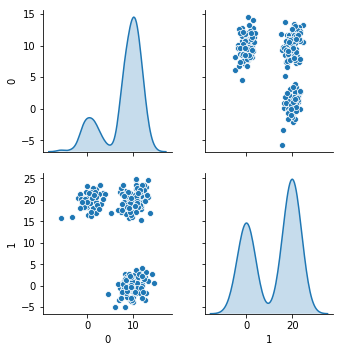

In [383]:
sns.pairplot(Hdf,diag_kind="kde")

### 11. Find out the linkage matrix

In [390]:
from scipy.cluster.hierarchy import cophenet, dendrogram, linkage
from scipy.spatial.distance import pdist  #Pairwise distribution between data points

In [394]:
Z = linkage(Hdf, 'complete')
c, coph_dists = cophenet(Z , pdist(Hdf))
c

0.9421859602837297

In [395]:
Z = linkage(Hdf, 'single')
c, coph_dists = cophenet(Z , pdist(Hdf))
c

0.9471915878682675

In [393]:
Z = linkage(Hdf, 'ward')
c, coph_dists = cophenet(Z , pdist(Hdf))
c

0.957512458292674

In [396]:
Z = linkage(Hdf)
c, coph_dists = cophenet(Z , pdist(Hdf))
c

0.9471915878682675

In [399]:
#Average linkage is giving the highest Cophent value 
Z = linkage(Hdf, 'average')
c, coph_dists = cophenet(Z , pdist(Hdf))
c

0.9608483918947528

In [403]:
Z[:10]

array([[1.94000000e+02, 2.47000000e+02, 3.40959131e-02, 2.00000000e+00],
       [1.31000000e+02, 1.37000000e+02, 4.03999573e-02, 2.00000000e+00],
       [1.88000000e+02, 2.23000000e+02, 6.07059847e-02, 2.00000000e+00],
       [4.90000000e+01, 5.70000000e+01, 6.93852802e-02, 2.00000000e+00],
       [2.00000000e+02, 2.08000000e+02, 8.26913442e-02, 2.00000000e+00],
       [5.00000000e+00, 7.20000000e+01, 9.21370297e-02, 2.00000000e+00],
       [4.10000000e+01, 8.90000000e+01, 9.24941720e-02, 2.00000000e+00],
       [7.00000000e+00, 1.10000000e+01, 9.39096910e-02, 2.00000000e+00],
       [6.00000000e+01, 6.60000000e+01, 9.82615058e-02, 2.00000000e+00],
       [7.40000000e+01, 9.10000000e+01, 1.03129777e-01, 2.00000000e+00]])

Use ward as linkage metric and distance as Eucledian

(249, 4)

In [405]:
#but as Ward is suggested in the assignment will use it for further 

Z = linkage(Hdf, 'ward')
c, coph_dists = cophenet(Z , pdist(Hdf))
c

0.957512458292674

In [406]:
Z.shape

(249, 4)

### 12. Plot the dendrogram for the consolidated dataframe

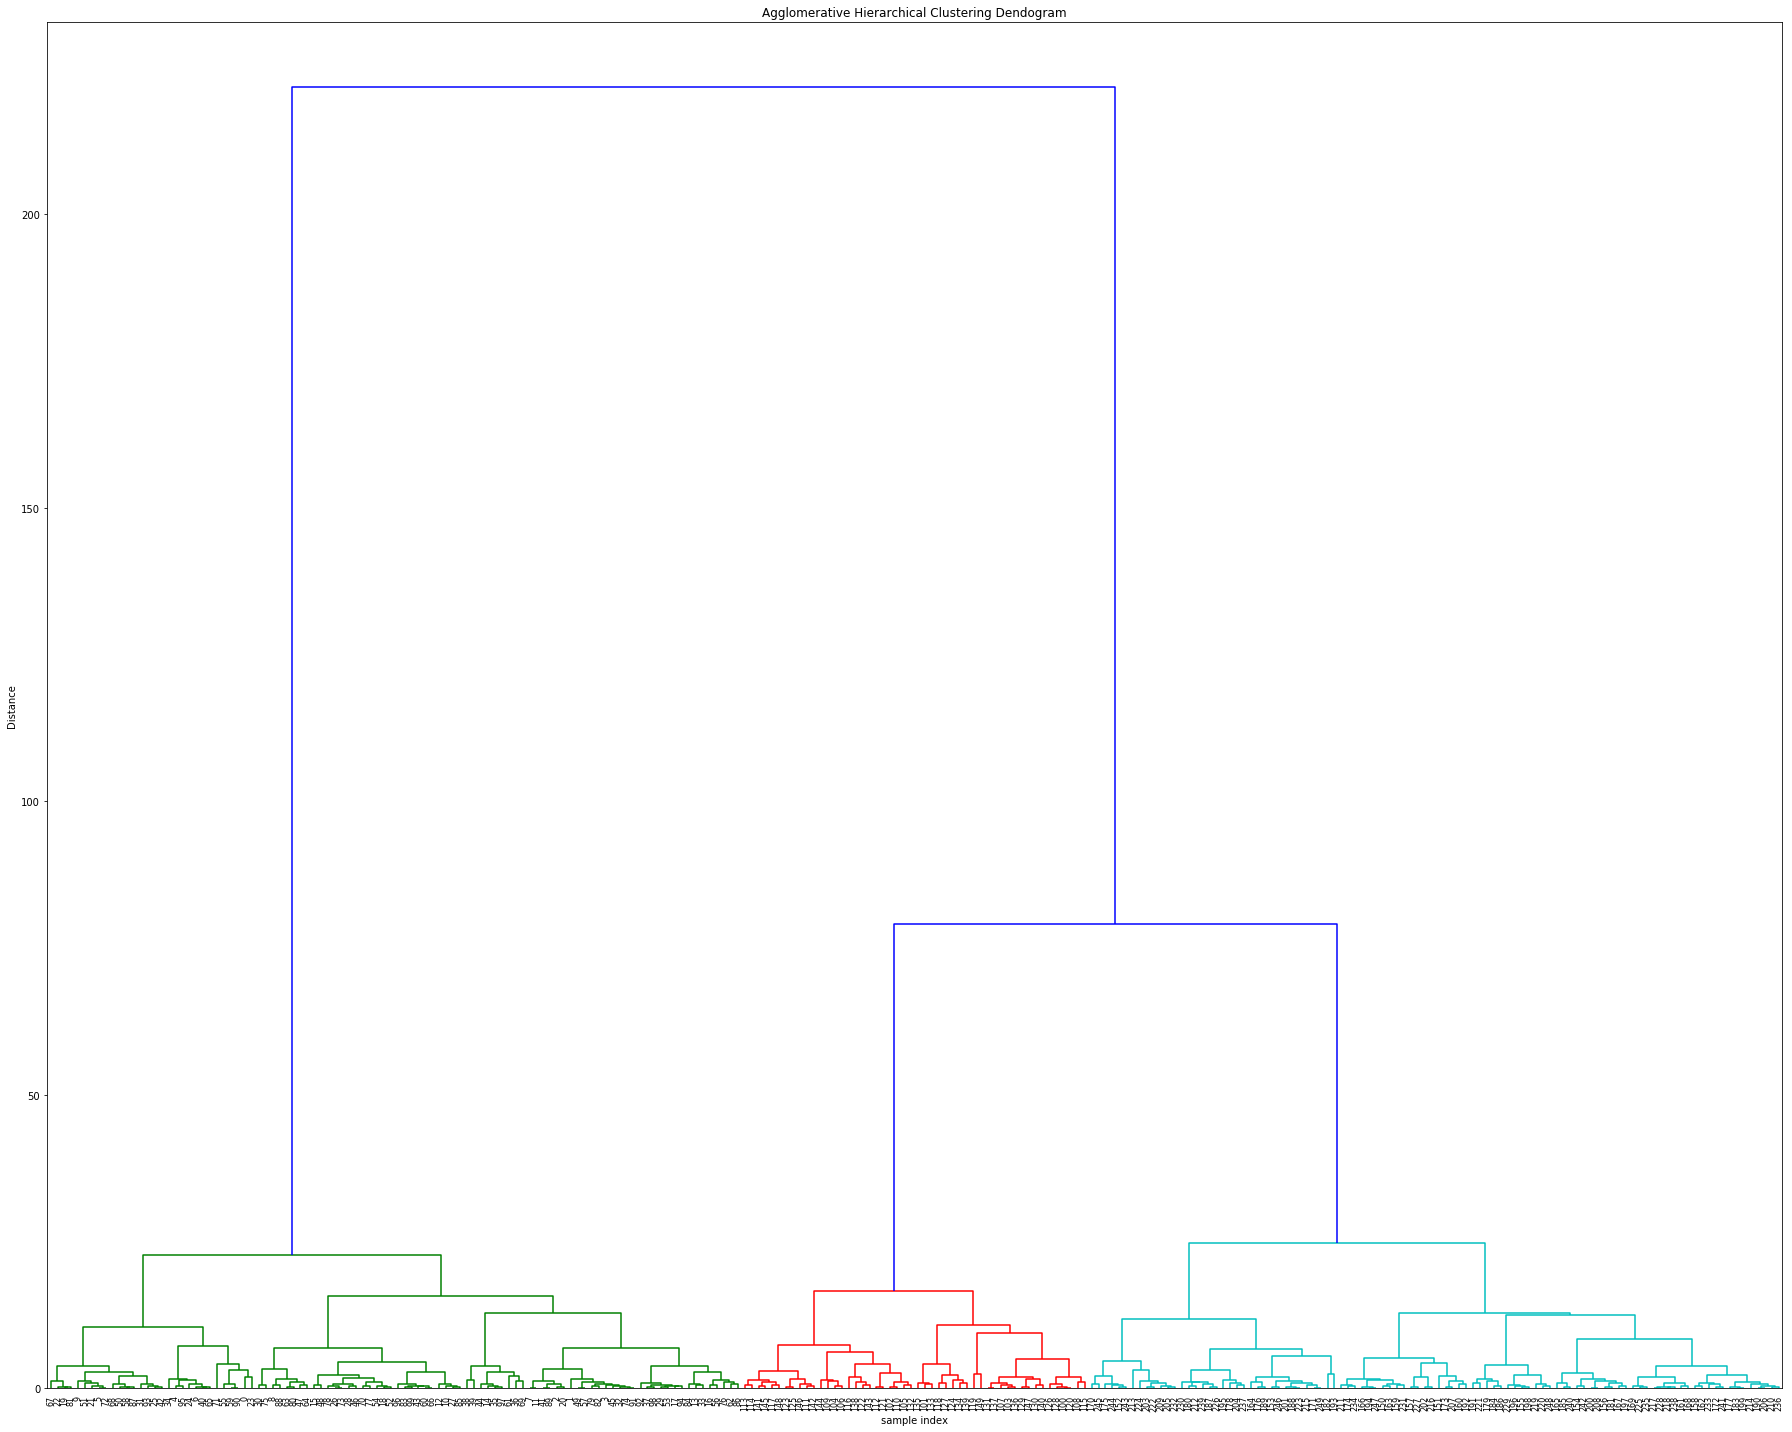

In [410]:
plt.figure(figsize=(25, 20))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, leaf_rotation=90.,color_threshold = 40, leaf_font_size=8. )
plt.tight_layout()

### 13. Recreate the dendrogram for last 12 merged clusters 

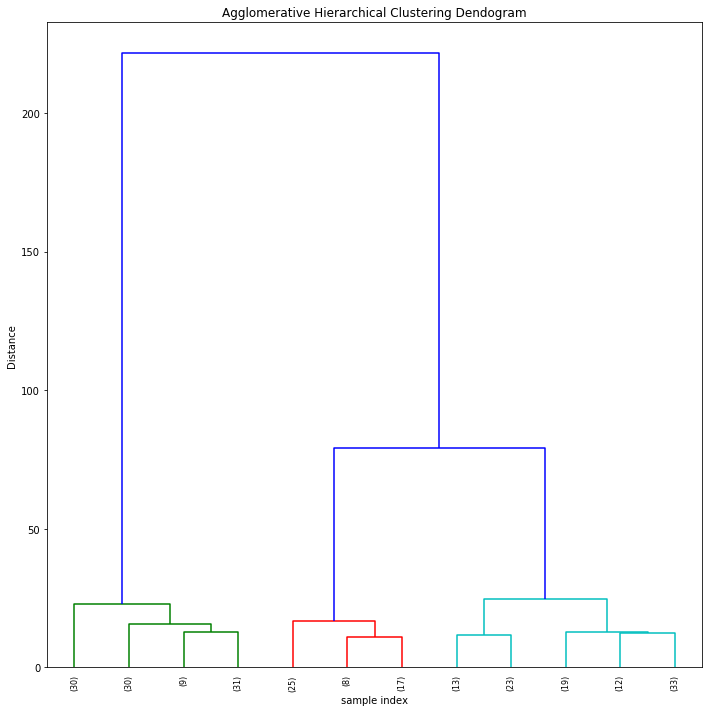

In [413]:
plt.figure(figsize=(10, 10))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, leaf_rotation=90.,color_threshold = 40, leaf_font_size=8., truncate_mode='lastp',p=12)
plt.tight_layout()

Hint: Use truncate_mode='lastp' attribute in dendrogram function to arrive at dendrogram 

### 14. From the truncated dendrogram, find out the optimal distance between clusters which u want to use an input for clustering data

In [ ]:
It seems the optimal distance between clusters to truncate can be set at 50

### 15. Using this distance measure and fcluster function to cluster the data into 3 different groups

In [414]:
from scipy.cluster.hierarchy import fcluster

In [417]:
max_d = 50
clusters = fcluster(Z, max_d, criterion='distance')
clusters

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3], dtype=int32)

### Use matplotlib to visually observe the clusters in 2D space 

In [438]:
HdfCluster.head()

,a,b
0,11.433577,2.997261
1,11.204713,-0.607057
2,12.240227,1.565389
3,10.535003,0.920263
4,12.213520,2.612081


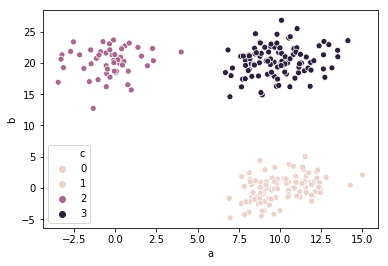

In [440]:
HdfCluster = Hdf.copy()
HdfCluster["c"] = clusters
sns.scatterplot(x=HdfCluster.a,y=HdfCluster.b,hue=HdfCluster.c)